# 08 — Treinamento adversário para imputação (GAIN sobre o BERT+FFT)

**Ideia.** Testar se um sinal adversarial melhora a imputação do melhor BERT do
orçamento longo. A perda MSE incentiva imputações "na média condicional" — suaves
demais, especialmente em blocos; um discriminador que tenta apontar o que foi imputado
força o gerador a produzir valores **indistinguíveis dos reais** em distribuição, não
só próximos na média.

**Formalização: GAIN (Yoon et al., 2018) adaptado.**

* **Gerador** = `BERTFFT` com FFT segmentada (o melhor BERT do notebook 07), que já
  consome as duas entradas do experimento: a janela pré-processada no domínio do
  tempo **e** os dados de frequência (token [FREQ] via FFT);
* **Discriminador** = Transformer pequeno (2 camadas, ~76 k parâmetros) que recebe a
  série **completada** (observados + imputações) + token [FREQ] e prediz, **posição a
  posição**, quais valores foram imputados (BCE contra a máscara) — sinal denso, mais
  estável que o real/falso por sequência dos GANs clássicos. Simplificação em relação
  ao GAIN original: sem vetor de *hint*;
* **Perda do gerador** = MSE mascarado (o de sempre, comparável) + λ_adv · BCE de
  enganar o discriminador nas posições imputadas, com **λ_adv = 0,1**.

**Salvaguardas.** Early stopping continua no MSE mascarado de validação do gerador
(máscaras fixas por época, as mesmas dos outros treinos) — se o jogo adversarial
atrapalhar a imputação, o critério seleciona um checkpoint anterior; o GAN não dita o
modelo final. Orçamento idêntico ao notebook 07 (300 épocas, paciência 30, semente 42).

**Comparação sem reexecutar nada**: os números dos 6 modelos do notebook 07 são
carregados de `resultados/metricas_fft_seg.csv` (mesmo protocolo, mesmas máscaras de
avaliação — semente 123). Artefatos novos: `resultados/adversarial/` e
`resultados/{metricas_adv,comparacao_adv}.{csv,json}`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, TINTA_2, DESTAQUE_MASCARA
from src.saits_fft import BERTFFT, carregar_bert_fft
from src.adversarial import DiscriminadorMascara, treinar_adversarial
from src.treino import fixar_semente
from src.avaliacao import avaliar_metodos, imputar_bert_lotes
from src.mascaramento import mascaras_avaliacao, trechos_mascarados

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
ds_treino = dados.JanelasDataset(arrays["treino"])
ds_val = dados.JanelasDataset(arrays["val"])
print(f"device: {device}  |  janelas de treino: {len(ds_treino):,}  |  validação: {len(ds_val):,}")

device: cuda  |  janelas de treino: 72,500  |  validação: 2,500


In [2]:
CFG = {
    "semente": 42,
    "epocas": 300,
    "batch": 256,
    "lr": 1e-3,
    "lr_d": 1e-3,
    "lambda_adv": 0.1,
    "paciencia": 30,
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
}
BASE = dict(seq_len=168, d_model=64, n_camadas=3, n_cabecas=4, d_ff=256, dropout=0.1)
N_SEG = 6

fixar_semente(CFG["semente"])
gerador = BERTFFT(**BASE, modo_fft="segmentada", n_segmentos=N_SEG)
discriminador = DiscriminadorMascara(seq_len=168, d_model=64, n_camadas=2,
                                     n_cabecas=4, d_ff=128,
                                     modo_fft="segmentada", n_segmentos=N_SEG)
nG = sum(p.numel() for p in gerador.parameters())
nD = sum(p.numel() for p in discriminador.parameters())
print(f"gerador (BERT+FFT segmentada): {nG:,} parâmetros — idêntico ao do notebook 07")
print(f"discriminador                : {nD:,} parâmetros (descartado após o treino)")

gerador (BERT+FFT segmentada): 159,425 parâmetros — idêntico ao do notebook 07
discriminador                : 76,289 parâmetros (descartado após o treino)


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
%%time
# treino adversarial (idempotente: pula se já houver historico.json)
pasta = Path("resultados/adversarial")
if (pasta / "historico.json").exists():
    print("[já treinado] carregando histórico salvo")
    with open(pasta / "historico.json", encoding="utf-8") as f:
        hist_adv = json.load(f)
else:
    hist_adv = treinar_adversarial(gerador, discriminador, ds_treino, ds_val,
                                   CFG, device, str(pasta))

época   1 | rec 0.2840 | adv 0.3013 | D 0.5608 | val 0.1159  <- melhor


época   2 | rec 0.1178 | adv 0.2980 | D 0.5581 | val 0.0899  <- melhor


época   3 | rec 0.1016 | adv 0.2971 | D 0.5580 | val 0.0810  <- melhor


época   4 | rec 0.0935 | adv 0.2974 | D 0.5575 | val 0.0755  <- melhor


época   5 | rec 0.0882 | adv 0.3002 | D 0.5563 | val 0.0742  <- melhor


...

época 151 | rec 0.0551 | adv 0.3418 | D 0.5370 | val 0.0526


época 152 | rec 0.0548 | adv 0.3430 | D 0.5372 | val 0.0544


época 153 | rec 0.0554 | adv 0.3432 | D 0.5366 | val 0.0525


época 154 | rec 0.0547 | adv 0.3418 | D 0.5373 | val 0.0534


época 155 | rec 0.0552 | adv 0.3428 | D 0.5372 | val 0.0541
early stopping (sem melhora há 30 épocas)
CPU times: total: 2h 6min 15s
Wall time: 2h 3min 58s


adversarial: 155 épocas | melhor val 0.0514 (época 125)


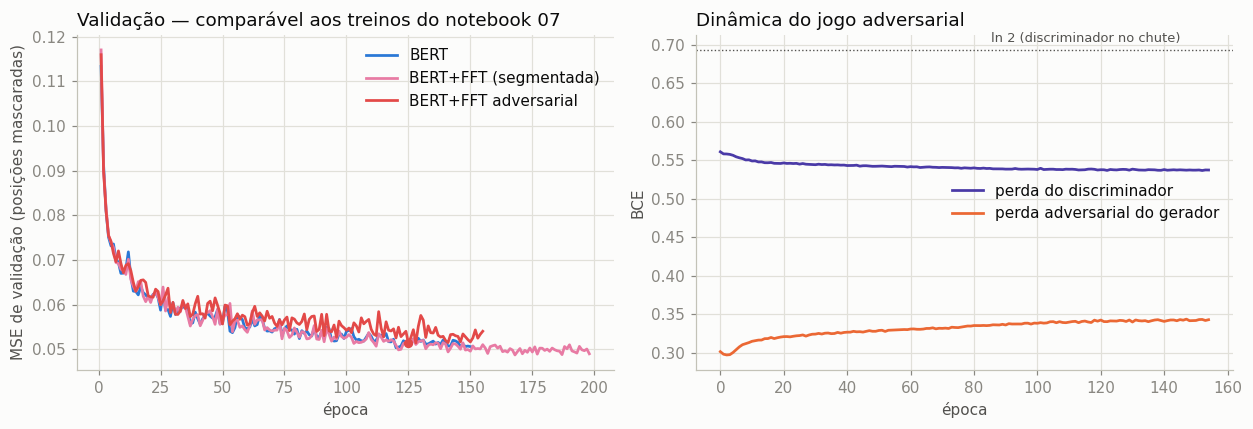

In [4]:
# curvas: validação (comparável) + dinâmica do jogo adversarial
CORES_MODELOS = {
    "BERT": PALETA["azul"],
    "BERT+FFT (segmentada)": PALETA["magenta"],
    "BERT+FFT adversarial": PALETA["vermelho"],
    "SAITS (DMSA+ORT)": PALETA["verde_agua"],
}
fig, (e1, e2) = plt.subplots(1, 2, figsize=(11.5, 4))

for nome, arq in [("BERT", "resultados/fft_segmentada/bert/historico.json"),
                  ("BERT+FFT (segmentada)", "resultados/fft_segmentada/bert_ffts/historico.json")]:
    with open(arq, encoding="utf-8") as f:
        h = json.load(f)
    val = [e["perda_val"] for e in h]
    e1.plot(range(1, len(val) + 1), val, color=CORES_MODELOS[nome], label=nome)
val_adv = [e["perda_val"] for e in hist_adv]
e1.plot(range(1, len(val_adv) + 1), val_adv, color=CORES_MODELOS["BERT+FFT adversarial"],
        label="BERT+FFT adversarial")
for nome, val in [("BERT+FFT adversarial", val_adv)]:
    m = int(np.argmin(val))
    e1.scatter(m + 1, val[m], s=26, color=CORES_MODELOS[nome], zorder=3)
print(f"adversarial: {len(val_adv)} épocas | melhor val {min(val_adv):.4f} "
      f"(época {int(np.argmin(val_adv)) + 1})")
e1.set_xlabel("época")
e1.set_ylabel("MSE de validação (posições mascaradas)")
e1.set_title("Validação — comparável aos treinos do notebook 07", loc="left")
e1.legend()

e2.plot([h["perda_D"] for h in hist_adv], color=PALETA["violeta"], label="perda do discriminador")
e2.plot([h["perda_adv"] for h in hist_adv], color=PALETA["laranja"], label="perda adversarial do gerador")
e2.axhline(np.log(2), color=TINTA_2, linewidth=0.9, linestyle=":")
e2.annotate("ln 2 (discriminador no chute)", (len(hist_adv) * 0.55, np.log(2)),
            textcoords="offset points", xytext=(0, 5), fontsize=8.5, color=TINTA_2)
e2.set_xlabel("época")
e2.set_ylabel("BCE")
e2.set_title("Dinâmica do jogo adversarial", loc="left")
e2.legend()
fig.tight_layout()
plt.show()

## Avaliação e comparação (sem reexecutar os modelos anteriores)

O modelo adversarial é avaliado no protocolo fixo; os 6 modelos do notebook 07 entram
pelos números já salvos em `resultados/metricas_fft_seg.csv` — mesmas máscaras de
avaliação determinísticas, portanto diretamente comparáveis.

In [5]:
%%time
j_teste, id_teste = arrays["teste"], arrays["id_teste"]
desvios = stats["desvio"].to_numpy()[id_teste].astype("float32")
medias = stats["media"].to_numpy()[id_teste].astype("float32")

modelo_adv = carregar_bert_fft("resultados/adversarial/melhor_modelo.pt", device)

cenarios = [
    (f"{tipo} {int(razao*100)}%", tipo, razao)
    for tipo in ("pontual", "bloco")
    for razao in (0.10, 0.25, 0.50)
]
res_adv = avaliar_metodos(
    j_teste, {"BERT+FFT adversarial": modelo_adv}, device, cenarios,
    semente=123, desvios=desvios, medias=medias,
)
res_adv.to_csv("resultados/metricas_adv.csv", index=False)
res_adv.to_json("resultados/metricas_adv.json", orient="records",
                indent=2, force_ascii=False)

res_07 = pd.read_csv("resultados/metricas_fft_seg.csv")
modelos_07 = ["BERT", "BERT+FFT (padrão)", "BERT+FFT (segmentada)",
              "SAITS (DMSA+ORT)", "SAITS-FFT (padrão)", "SAITS-FFT (segmentada)"]
res_tudo = pd.concat([res_07[res_07["método"].isin(modelos_07)],
                      res_adv[res_adv["método"] == "BERT+FFT adversarial"]],
                     ignore_index=True)
res_adv.round(4)

C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


CPU times: total: 32.4 s
Wall time: 18.2 s


,cenário,método,MAE,RMSE,MAE_kW,RMSE_kW,MRE
0,pontual 10%,BERT+FFT adversarial,0.1201,0.1947,13.0462,44.8480,0.0390
1,pontual 10%,média da janela,0.7789,0.9239,106.8868,308.9570,0.3194
2,pontual 10%,último valor (ffill),0.2929,0.4686,35.6964,145.3564,0.1067
3,pontual 10%,interpolação linear,0.1841,0.2884,21.5006,78.1609,0.0642
4,pontual 25%,BERT+FFT adversarial,0.1248,0.1971,13.3515,43.0190,0.0400
5,pontual 25%,média da janela,0.7808,0.9250,106.7318,306.4373,0.3195
6,pontual 25%,último valor (ffill),0.3313,0.5311,40.6077,169.0464,0.1216
7,pontual 25%,interpolação linear,0.2056,0.3170,24.4568,90.7781,0.0732
8,pontual 50%,BERT+FFT adversarial,0.1430,0.2244,15.3088,49.8634,0.0460
9,pontual 50%,média da janela,0.7819,0.9274,106.7003,304.3590,0.3203


In [6]:
# tabela: 7 modelos lado a lado + deltas do adversarial
nomes_cen = [c[0] for c in cenarios]
ordem_modelos = modelos_07 + ["BERT+FFT adversarial"]
tabela_mae = (res_tudo.pivot(index="cenário", columns="método", values="MAE")
              .loc[nomes_cen, ordem_modelos])
tabela_mae.to_csv("resultados/comparacao_adv.csv", encoding="utf-8-sig")

deltas = pd.DataFrame({
    "Adv vs BERT+FFTs (gêmeo)": 100 * (tabela_mae["BERT+FFT adversarial"]
                                       - tabela_mae["BERT+FFT (segmentada)"])
                                / tabela_mae["BERT+FFT (segmentada)"],
    "Adv vs BERT": 100 * (tabela_mae["BERT+FFT adversarial"] - tabela_mae["BERT"])
                   / tabela_mae["BERT"],
})
print("salvo: resultados/comparacao_adv.csv")
display(tabela_mae.round(4))
deltas.round(2)

salvo: resultados/comparacao_adv.csv


método,BERT,BERT+FFT (padrão),BERT+FFT (segmentada),SAITS (DMSA+ORT),SAITS-FFT (padrão),SAITS-FFT (segmentada),BERT+FFT adversarial
cenário,,,,,,,
pontual 10%,0.1193,0.1150,0.1153,0.1147,0.1153,0.1149,0.1201
pontual 25%,0.1244,0.1209,0.1207,0.1206,0.1208,0.1208,0.1248
pontual 50%,0.1428,0.1405,0.1392,0.1388,0.1396,0.1399,0.1430
bloco 10%,0.1604,0.1559,0.1562,0.1575,0.1563,0.1567,0.1615
bloco 25%,0.1628,0.1587,0.1589,0.1599,0.1590,0.1590,0.1643
bloco 50%,0.1737,0.1709,0.1698,0.1709,0.1708,0.1711,0.1757


,Adv vs BERT+FFTs (gêmeo),Adv vs BERT
cenário,,
pontual 10%,4.19,0.64
pontual 25%,3.39,0.32
pontual 50%,2.71,0.14
bloco 10%,3.35,0.69
bloco 25%,3.43,0.96
bloco 50%,3.48,1.14


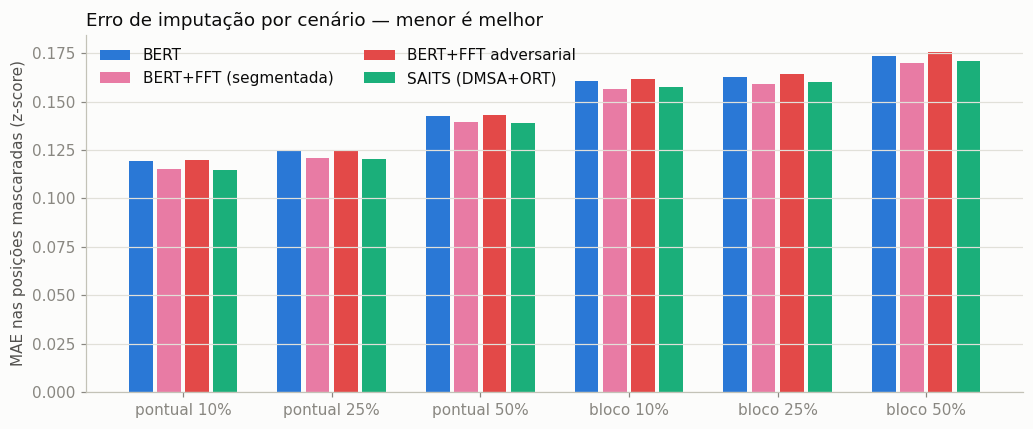

In [7]:
# barras: o adversarial contra o gêmeo não-adversarial e as referências
ordem = ["BERT", "BERT+FFT (segmentada)", "BERT+FFT adversarial", "SAITS (DMSA+ORT)"]
x = np.arange(len(nomes_cen))
larg = 0.19

fig, eixo = plt.subplots(figsize=(9.5, 4))
for k, met in enumerate(ordem):
    v = tabela_mae.loc[nomes_cen, met].to_numpy()
    eixo.bar(x + (k - 1.5) * larg, v, width=larg - 0.03,
             color=CORES_MODELOS[met], label=met)
eixo.set_xticks(x)
eixo.set_xticklabels(nomes_cen)
eixo.set_ylabel("MAE nas posições mascaradas (z-score)")
eixo.set_title("Erro de imputação por cenário — menor é melhor", loc="left")
eixo.legend(ncols=2, loc="upper left")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


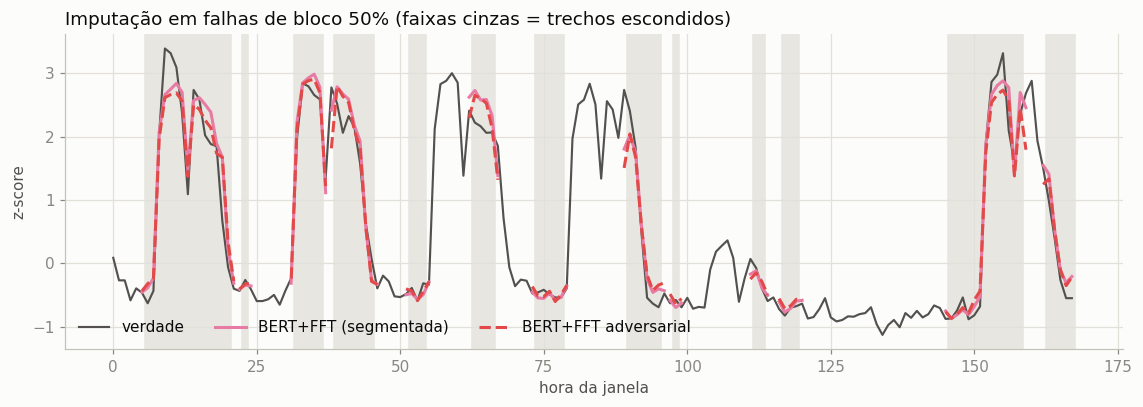

In [8]:
# exemplo qualitativo: o adversarial deixa a imputação menos suavizada?
modelo_ffts = carregar_bert_fft("resultados/fft_segmentada/bert_ffts/melhor_modelo.pt", device)
idx_exemplo = 17
x_ex = torch.from_numpy(j_teste[idx_exemplo : idx_exemplo + 1])
masc = mascaras_avaliacao(1, x_ex.shape[1], "bloco", 0.50, semente=7)
imput_ffts = imputar_bert_lotes(modelo_ffts, x_ex, masc, device)[0].numpy()
imput_adv = imputar_bert_lotes(modelo_adv, x_ex, masc, device)[0].numpy()

m = masc[0].numpy()
t = np.arange(x_ex.shape[1])
fig, eixo = plt.subplots(figsize=(10.5, 3.8))
for ini, fim in trechos_mascarados(m):
    eixo.axvspan(ini - 0.5, fim - 0.5, color=DESTAQUE_MASCARA, zorder=0)
eixo.plot(t, x_ex[0], color=TINTA_2, linewidth=1.4, label="verdade")
primeiro = trechos_mascarados(m)[0][0]
for ini, fim in trechos_mascarados(m):
    tr = slice(max(ini - 1, 0), min(fim + 1, len(t)))
    eixo.plot(t[tr], imput_ffts[tr], color=PALETA["magenta"], linewidth=2.0,
              label="BERT+FFT (segmentada)" if ini == primeiro else None)
    eixo.plot(t[tr], imput_adv[tr], color=PALETA["vermelho"], linewidth=2.0, linestyle="--",
              label="BERT+FFT adversarial" if ini == primeiro else None)
eixo.set_xlabel("hora da janela")
eixo.set_ylabel("z-score")
eixo.set_title("Imputação em falhas de bloco 50% (faixas cinzas = trechos escondidos)", loc="left")
eixo.legend(ncols=3)
fig.tight_layout()
plt.show()

In [9]:
# resumo por tipo de cenário
resumo = []
for tipo in ("pontual", "bloco"):
    sel = [c for c in nomes_cen if c.startswith(tipo)]
    linha = {"tipo": tipo}
    for met in ordem:
        linha[met] = tabela_mae.loc[sel, met].mean()
    linha["Δ% Adv vs gêmeo"] = 100 * (linha["BERT+FFT adversarial"]
                                      - linha["BERT+FFT (segmentada)"]) / linha["BERT+FFT (segmentada)"]
    resumo.append(linha)
resumo = pd.DataFrame(resumo).set_index("tipo")
resumo.round(4)

,BERT,BERT+FFT (segmentada),BERT+FFT adversarial,SAITS (DMSA+ORT),Δ% Adv vs gêmeo
tipo,,,,,
pontual,0.1288,0.1251,0.1293,0.1247,3.3818
bloco,0.1656,0.1616,0.1672,0.1628,3.4198


## Conclusões

**Resultado negativo, limpo e informativo: o treinamento adversário PIOROU a
imputação em todos os cenários.**

- **Contra o gêmeo não-adversarial** (mesma arquitetura BERT+FFT segmentada, mesmo
  orçamento, mesma semente — a única diferença é o termo adversarial): MAE **+2,7 % a
  +4,2 %** pior nos 6 cenários (média +3,4 %) e RMSE +1,8 % a +3,3 % pior. O
  adversarial devolve quase todo o ganho que a FFT tinha dado: fica ≈ empatado com o
  BERT puro (+0,1 % a +1,1 %).
- **Não foi instabilidade de GAN.** O jogo se manteve saudável do início ao fim: a
  perda do discriminador estabilizou em ~0,54 (abaixo de ln 2 ≈ 0,69 — ele acerta um
  pouco mais que o chute, sem colapsar nem dominar) e a validação do gerador caiu
  monotonicamente até a época 125 (0,0514), com early stopping normal na 155. O
  resultado reflete o método, não um treino divergente.
- **Por que piora: o conflito de objetivos é estrutural.** MAE/RMSE premiam a média
  condicional; o termo adversarial empurra as imputações para *parecerem amostras
  reais* — com a variância e a textura do dado — o que necessariamente as afasta da
  média condicional. Para as métricas pontuais deste protocolo, realismo
  distribucional e acurácia pontual são objetivos em tensão; com λ_adv = 0,1 a tensão
  custou ~3,4 % de MAE. O ganho de "realismo" pode ter valor em outras aplicações
  (ex.: simulação, dados sintéticos), mas não na imputação avaliada por erro pontual.
- Comparação direta com a validação: gêmeo 0,0488 (época 168) vs adversarial 0,0514
  (época 125) — a diferença já era visível na validação, confirmando que o teste não
  trouxe surpresa.

**Leitura para o trabalho.** Este experimento fecha a segunda sugestão de contribuição
(tempo + frequência com treino adversário) com um resultado negativo bem
caracterizado, na linha da crítica do próprio artigo do SAITS aos imputadores GAN. As
ressalvas de sempre: uma semente (42), um único λ_adv (0,1) — valores menores devem
apenas interpolar em direção ao gêmeo; a variante com *hint* do GAIN original não foi
testada.

**Artefatos** (nada anterior foi sobrescrito): `resultados/adversarial/`
(`melhor_modelo.pt` = gerador, `discriminador.pt`, `historico.json` com as perdas
rec/adv/D/val), `resultados/metricas_adv.{csv,json}` e
`resultados/comparacao_adv.csv` (7 modelos, aproveitando o notebook 07 sem
reexecução).